## 1. Business Understanding

### Background

UMKM merupakan salah satu pilar utama perekonomian Indonesia. Berdasarkan data
Kementerian Koordinator Bidang Perekonomian RI (2023), Indonesia memiliki 65,5 juta
UMKM yang berkontribusi sebesar 61% terhadap PDB nasional serta menyerap 97% dari
total tenaga kerja nasional.

Namun, pelaku usaha mikro masih menghadapi kendala serius dalam pengelolaan keuangan.
Sholikah et al. (2023) menemukan bahwa sebagian besar pelaku usaha toko sembako hanya
mengandalkan ingatan dalam mencatat keuangan. Kondisi ini menyebabkan proses rekap
keuangan menjadi lambat, rentan terhadap kesalahan, serta menyulitkan pelaku usaha
dalam mengetahui laba dan kondisi bisnis secara real-time.

---

### Problem Statement

Pelaku usaha mikro di Indonesia masih mengandalkan pencatatan transaksi secara manual
melalui struk fisik atau bahkan hanya mengandalkan ingatan. Kondisi ini menyebabkan
tiga permasalahan utama:

1. Proses rekap keuangan lambat dan rawan human error
2. Kesulitan menghitung laba per item secara akurat
3. Tidak tersedianya laporan keuangan terstruktur untuk pengambilan keputusan bisnis

---

### Solusi

NOPI (Nota Pintar) merupakan aplikasi berbasis OCR dengan pipeline dua tahap:

1. **Klasifikasi CNN** untuk memfilter gambar input secara otomatis dan membedakan
   gambar struk dari gambar non-struk sebelum diproses lebih lanjut
2. **Ekstraksi OCR** untuk mengambil informasi terstruktur (nama item, harga satuan,
   dan total transaksi) dari gambar struk yang telah terdeteksi

---

### Business Question

1. Bagaimana teknologi OCR dapat dimanfaatkan untuk mengekstrak informasi dari struk secara otomatis dan akurat?

2. Bagaimana pelaku usaha mikro dapat mengetahui estimasi laba dari setiap produk yang dijual secara sederhana dan efisien?

3. Bagaimana data transaksi hasil OCR dapat diolah menjadi laporan terstruktur untuk mendukung pengambilan keputusan bisnis?

---

### Indikator Pengukuran Business Question

| Business Question | Indikator Pengukuran |
|---|---|
| BQ1 | Perbandingan model OCR berdasarkan success rate, akurasi item, akurasi total harga, dan waktu proses. |
| BQ2 | Estimasi laba dihitung dari total harga item menggunakan asumsi margin laba tertentu. |
| BQ3 | Data transaksi dinilai dari kelengkapan kolom, jumlah data bersih, missing value, duplikat, validitas tanggal, serta ringkasan penjualan. |

---

### Analytical Question

1. Apakah dataset gambar struk dan non-struk sudah cukup bersih, seimbang, dan
   representatif untuk melatih model CNN classifier dengan akurasi minimal 85%,
   sehingga NOPI dapat memfilter input pengguna sebelum proses ekstraksi OCR?

---

### Success Criteria

| Kriteria         | Target                                         |
|------------------|------------------------------------------------|
| Akurasi CNN      | Minimal 85%                                    |
| Kualitas dataset | Tidak ada duplikat, file corrupt, atau missing |
| Class balance    | Rasio struk : non-struk maksimal 3 : 1         |
| Format output    | Folder gambar terorganisir dan terdokumentasi  |

## 2. Setup & Import Library

In [1]:
!pip install pandas numpy matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport.')

Library berhasil diimport.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/NOPI/output_csv'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


## 3. Gathering Data

Pada tahap ini, data yang digunakan berasal dari output Tim AI Project NOPI dalam bentuk 4 file CSV.

| Dataset | Keterangan |
|---|---|
| `Dataset_Terstruktur_Primer_NOPI.csv` | Dataset utama hasil ekstraksi 117 struk primer menggunakan PaddleOCR |
| `evaluasi_3_model.csv` | Ringkasan performa 3 model OCR |
| `detail_akurasi_semua_model.csv` | Detail akurasi dan status parsing tiap model OCR |
| `hasil_komparasi_ocr_final.csv` | Data benchmark mentah dari 30 sampel struk |

Dataset utama digunakan untuk proses cleaning dan analisis transaksi, sedangkan tiga dataset lainnya digunakan untuk evaluasi performa OCR.

In [4]:
BASE = '/content/drive/MyDrive/NOPI'

df_primer    = pd.read_csv(f'{BASE}/Dataset_Terstruktur_Primer_NOPI.csv')
df_evaluasi  = pd.read_csv(f'{BASE}/evaluasi_3_model.csv')
df_detail    = pd.read_csv(f'{BASE}/detail_akurasi_semua_model.csv')
df_komparasi = pd.read_csv(f'{BASE}/hasil_komparasi_ocr_final.csv')

print('Dataset berhasil dimuat.')

Dataset berhasil dimuat.


In [5]:
# Preview Dataset_Terstruktur_Primer_NOPI.csv
print(f'Shape : {df_primer.shape}')
print(f'Kolom : {list(df_primer.columns)}')
display(df_primer.head())

Shape : (337, 10)
Kolom : ['nomor', 'filename', 'sumber', 'nama_toko', 'tanggal', 'nama_barang', 'jumlah_barang', 'harga_satuan', 'total_harga_item', 'raw_text']


,nomor,filename,sumber,nama_toko,tanggal,nama_barang,jumlah_barang,harga_satuan,total_harga_item,raw_text
0,1,primer_0000.jpg,primer,SOTO AYOM RCKOG,19-11-201,NaN,NaN,NaN,NaN,SOTO AYOM RCKOG\nKUTOS POS PNVONG\nSEMAPONG\n1...
1,2,primer_0001.jpg,primer,watsons,NaN,NaN,NaN,NaN,NaN,watsons\niook good teel great\nWATSONS INDONES...
2,3,primer_0002.jpg,primer,ALFAMIDI ADISUMARMO,19-05-2022,NaN,NaN,NaN,NaN,ALFAMIDI ADISUMARMO\nADISUMARM0/081226636221\n...
3,4,primer_0003.jpg,primer,Central Park,NaN,Central Park,3.0,4000.0,0.0,"Central Park\n3X4.000\nRp\nPOPMIERBASO57G\n12,..."
4,5,primer_0003.jpg,primer,Central Park,NaN,"1,200-",3.0,4000.0,6.0,"Central Park\n3X4.000\nRp\nPOPMIERBASO57G\n12,..."


In [6]:
# Preview evaluasi_3_model.csv
print(f'Shape : {df_evaluasi.shape}')
print(f'Kolom : {list(df_evaluasi.columns)}')
display(df_evaluasi)

Shape : (3, 5)
Kolom : ['Nama Model', 'Rata-rata Waktu (Detik)', 'Success Rate (%)', 'Akurasi Jumlah Item (%)', 'Akurasi Total Harga (%)']


,Nama Model,Rata-rata Waktu (Detik),Success Rate (%),Akurasi Jumlah Item (%),Akurasi Total Harga (%)
0,Paddle,5.26,73.33,27.30,26.09
1,Tesseract,2.64,60.00,13.67,16.05
2,EasyOCR,18.73,56.67,33.47,14.03


In [7]:
# Preview detail_akurasi_semua_model.csv
print(f'Shape : {df_detail.shape}')
print(f'Kolom : {list(df_detail.columns)}')
display(df_detail.head())

Shape : (90, 9)
Kolom : ['Nama File', 'Model', 'Item Asli (GT)', 'Item Terbaca', 'Total Harga Asli (GT)', 'Total Harga Terbaca', 'Akurasi Item (%)', 'Akurasi Harga (%)', 'Status']


,Nama File,Model,Item Asli (GT),Item Terbaca,Total Harga Asli (GT),Total Harga Terbaca,Akurasi Item (%),Akurasi Harga (%),Status
0,primer_0002.jpg,Paddle,1,0,38200,0,0.0,0.0,Gagal Total (0%)
1,primer_0002.jpg,Tesseract,1,0,38200,0,0.0,0.0,Gagal Total (0%)
2,primer_0002.jpg,EasyOCR,1,4,38200,726111,0.0,0.0,Sebagian (Terekstrak tapi ada miss)
3,primer_0031.jpg,Paddle,1,0,32000,0,0.0,0.0,Gagal Total (0%)
4,primer_0031.jpg,Tesseract,1,1,32000,0,100.0,0.0,Sebagian (Terekstrak tapi ada miss)


In [8]:
# Preview hasil_komparasi_ocr_final.csv
print(f'Shape : {df_komparasi.shape}')
print(f'Kolom : {list(df_komparasi.columns)}')
display(df_komparasi.head())

Shape : (30, 10)
Kolom : ['File', 'Waktu_Paddle', 'Raw_Paddle', 'Hasil_Paddle', 'Waktu_Tesseract', 'Raw_Tesseract', 'Hasil_Tesseract', 'Waktu_EasyOCR', 'Raw_EasyOCR', 'Hasil_EasyOCR']


,File,Waktu_Paddle,Raw_Paddle,Hasil_Paddle,Waktu_Tesseract,Raw_Tesseract,Hasil_Tesseract,Waktu_EasyOCR,Raw_EasyOCR,Hasil_EasyOCR
0,dataset_struk/primer_0002.jpg,3.35,ALFAMIDI ADISUMARMO\nADISUMARM0/081226636221\n...,"{\n ""nama_toko"": ""ALFAMIDI ADISUMARMO"",\n ...",5.43,ALFAMIOT ADISUMARMO\nADT SUMARMO/08122663622\n...,"{\n ""nama_toko"": ""ALFAMIOT ADISUMARMO"",\n ...",30.99,"[{'bbox': [[317, 47], [421, 47], [421, 83], [3...","{\n ""nama_toko"": ""ALFAHIDI ADISUMARMO"",\n ..."
1,dataset_struk/primer_0031.jpg,3.15,SOXEVNSPAETAIEADRAR\nIadomarty\nAVAPTAURARA\n0...,"{\n ""nama_toko"": ""SOXEVNSPAETAIEADRAR"",\n ...",0.69,_— on\n4 Se: megan “t\n\n’\n\n%\n\nLe tna een)...,"{\n ""nama_toko"": ""_\u2014 on"",\n ""tangga...",2.65,"[{'bbox': [[289, 441], [321, 441], [321, 455],...","{\n ""nama_toko"": ""NOT FOUND"",\n ""tanggal..."
2,dataset_struk/primer_0051.jpg,2.92,TOKOSUKATANT\nTOKO SUKATANI\nPerumahan Pondok ...,"{\n ""nama_toko"": ""TOKOSUKATANT"",\n ""tang...",1.41,TOKO SUKATANT\n\nTOKO SUKATAN\n\nPerumahian Po...,"{\n ""nama_toko"": ""TOKO SUKATANT"",\n ""tan...",14.13,"[{'bbox': [[273, 187], [361, 187], [361, 251],...","{\n ""nama_toko"": ""TOKO SUKATAH"",\n ""tang..."
3,dataset_struk/primer_0085.jpg,4.12,TONGTjI\nCV.Mega Artha Semesta\nJ1.Jend.A.Yani...,"{\n ""nama_toko"": ""TONGTjI"",\n ""tanggal"":...",5.32,""" e\n’ .\n. . ’ ; ' . ‘\nra ‘ y 7 *\nA ‘ e . ""...","{\n ""nama_toko"": ""\"" e"",\n ""tanggal"": ""1...",18.38,"[{'bbox': [[343, 127], [447, 127], [447, 171],...","{\n ""nama_toko"": ""TMNGJJ\u00ed"",\n ""tang..."
4,dataset_struk/primer_0021.jpg,4.56,MOTHERCARE\nPT.MULTITREN INDO\nNPWP 02 109702....,"{\n ""nama_toko"": ""MOTHERCARE"",\n ""tangga...",0.84,MOTHE RCARE\nPT MU TIT Rae INDO\nNPWP 02 169 7...,"{\n ""nama_toko"": ""MOTHE RCARE"",\n ""tangg...",11.14,"[{'bbox': [[69, 0], [346, 0], [346, 62], [69, ...","{\n ""nama_toko"": ""MOTHERCARE"",\n ""tangga..."


## 4. Assessing Data

Assessing dilakukan pada setiap dataset untuk memahami kondisi awal sebelum proses cleaning.
Karena data yang digunakan berbentuk CSV hasil OCR dan evaluasi model, aspek yang diperiksa disesuaikan dengan karakteristik masing-masing dataset.

Analisis assessing mencakup beberapa aspek utama:

1. **Struktur data:** jumlah baris, jumlah kolom, nama kolom, dan tipe data.
2. **Missing values:** mendeteksi nilai kosong pada kolom penting seperti nama barang, jumlah barang, harga, tanggal, dan hasil OCR.
3. **Duplikasi:** memeriksa apakah terdapat baris duplikat pada setiap dataset.
4. **Validitas transaksi:** mengecek kualitas data transaksi pada `df_primer`, seperti harga bernilai 0, total harga kosong, tanggal tidak terbaca, dan potensi inkonsistensi harga.
5. **Kesiapan analisis:** menentukan dataset mana yang memerlukan cleaning dan dataset mana yang sudah cukup terstruktur untuk langsung digunakan.

Assessing mendalam dilakukan pada `df_primer` karena dataset ini merupakan hasil ekstraksi OCR langsung dari struk dan digunakan sebagai dataset utama untuk analisis transaksi. Sementara itu, `df_evaluasi`, `df_detail`, dan `df_komparasi` dicek secara ringkas karena berfungsi sebagai dataset pendukung untuk evaluasi performa model OCR.

In [9]:
# Informasi dasar
print(f'Shape : {df_primer.shape}')
print(f'Jumlah struk : {df_primer["filename"].nunique()} file unik')

Shape : (337, 10)
Jumlah struk : 118 file unik


In [10]:
# Missing values
print('Missing Values:')
missing = df_primer.isnull().sum()
if missing.sum() == 0:
    print('Tidak ada missing value')
else:
    for col, val in missing[missing > 0].items():
        print(f'{col}: {val} ({val/len(df_primer)*100:.1f}%)')

Missing Values:
tanggal: 40 (11.9%)
nama_barang: 46 (13.6%)
jumlah_barang: 46 (13.6%)
harga_satuan: 46 (13.6%)
total_harga_item: 46 (13.6%)


In [11]:
# Duplikat
dup = df_primer.duplicated().sum()
print(f'Duplikat: {dup} baris ({dup/len(df_primer)*100:.1f}%)')

Duplikat: 0 baris (0.0%)


In [12]:
# Evaluasi kolom tanggal
tidak_terbaca = df_primer['tanggal'].isna().sum()
print(f'Tanggal kosong: {tidak_terbaca} ({tidak_terbaca/len(df_primer)*100:.1f}%)')
print()
print('Distribusi Tanggal:')
print(df_primer['tanggal'].value_counts().head(10).to_string())

Tanggal kosong: 40 (11.9%)

Distribusi Tanggal:
tanggal
20.10.2015    112
11-05-1908     23
16.01.2025     18
2026-01-24      9
21.01.22        8
10/11/2022      7
31.01.2025      6
11/01/2018      6
2026-03-31      5
2021-03-15      5


In [13]:
# Evaluasi kolom harga
total = len(df_primer)
harga_0   = (df_primer['harga_satuan'] == 0).sum()
total_0   = (df_primer['total_harga_item'] == 0).sum()
noise     = (df_primer['harga_satuan'] > 1_000_000).sum()
inkonsisten = (
    (df_primer['total_harga_item'] > 0) &
    (df_primer['harga_satuan'] > 0) &
    (df_primer['total_harga_item'] != df_primer['harga_satuan'] * df_primer['jumlah_barang'])
).sum()

print('Harga:')
print(f'harga_satuan = 0      : {harga_0} ({harga_0/total*100:.1f}%)')
print(f'total_harga_item = 0  : {total_0} ({total_0/total*100:.1f}%)')
print(f'Harga > 1 juta (noise): {noise} ({noise/total*100:.1f}%)')
print(f'Inkonsisten           : {inkonsisten} ({inkonsisten/total*100:.1f}%)')

Harga:
harga_satuan = 0      : 2 (0.6%)
total_harga_item = 0  : 17 (5.0%)
Harga > 1 juta (noise): 3 (0.9%)
Inkonsisten           : 33 (9.8%)


In [14]:
# Evaluasi kolom nama barang
noise_keywords = ['subtotal', 'total', 'sub tot', 'cash',
                  'change', 'debit', 'tanggal', 'faktur', 'jl.']

total_nb = df_primer['nama_barang'].notna().sum()
noise_nb = (
    (df_primer['nama_barang'].dropna().str.len() <= 2) |
    (df_primer['nama_barang'].dropna().str.match(r'^[\d\s,\.]+$')) |
    (df_primer['nama_barang'].dropna().str.lower().str.contains('|'.join(noise_keywords)))
).sum()

print('Nama Barang:')
print(f'Total terisi : {total_nb}')
print(f'Total noise  : {noise_nb} ({noise_nb/total_nb*100:.1f}%)')
print(f'Contoh       : {df_primer["nama_barang"].dropna().head(3).tolist()}')

Nama Barang:
Total terisi : 291
Total noise  : 36 (12.4%)
Contoh       : ['Central Park', '1,200-', '1,200-']


In [15]:
# Evaluasi kolom nama toko
print('Distribusi Nama Toko (top 10):')
print()
print(df_primer['nama_toko'].value_counts().head(10).to_string())

Distribusi Nama Toko (top 10):

nama_toko
PT Depok Distribusindo Raya      35
KOTA LEGENDA                     23
NOTA PENJUALAN (ASLI)            13
Depok Distribusindo Baya         10
PT Denok Distribusindo Raya      10
TOKOSUKATAM                       9
2153228346                        9
2153192428                        9
FT Depok Distribusiado Rsya       8
TLOGOMAS44 MALANG 08113336422     8


In [16]:
# Assessing df_evaluasi
print('ASSESSING: evaluasi_3_model.csv')
missing_ev = df_evaluasi.isnull().sum().sum()
dup_ev = df_evaluasi.duplicated().sum()
print(f'Missing values: {missing_ev}')
print(f'Duplikat      : {dup_ev}')
display(df_evaluasi)

ASSESSING: evaluasi_3_model.csv
Missing values: 0
Duplikat      : 0


,Nama Model,Rata-rata Waktu (Detik),Success Rate (%),Akurasi Jumlah Item (%),Akurasi Total Harga (%)
0,Paddle,5.26,73.33,27.30,26.09
1,Tesseract,2.64,60.00,13.67,16.05
2,EasyOCR,18.73,56.67,33.47,14.03


In [17]:
# Assessing df_detail
print('ASSESSING: detail_akurasi_semua_model.csv')
missing_dt = df_detail.isnull().sum().sum()
dup_dt = df_detail.duplicated().sum()
print(f'Missing values: {missing_dt}')
print(f'Duplikat      : {dup_dt}')

ASSESSING: detail_akurasi_semua_model.csv
Missing values: 0
Duplikat      : 0


In [18]:
display(df_detail.head())

,Nama File,Model,Item Asli (GT),Item Terbaca,Total Harga Asli (GT),Total Harga Terbaca,Akurasi Item (%),Akurasi Harga (%),Status
0,primer_0002.jpg,Paddle,1,0,38200,0,0.0,0.0,Gagal Total (0%)
1,primer_0002.jpg,Tesseract,1,0,38200,0,0.0,0.0,Gagal Total (0%)
2,primer_0002.jpg,EasyOCR,1,4,38200,726111,0.0,0.0,Sebagian (Terekstrak tapi ada miss)
3,primer_0031.jpg,Paddle,1,0,32000,0,0.0,0.0,Gagal Total (0%)
4,primer_0031.jpg,Tesseract,1,1,32000,0,100.0,0.0,Sebagian (Terekstrak tapi ada miss)


In [19]:
# Assessing df_komparasi
print('ASSESSING: hasil_komparasi_ocr_final.csv')
missing_kom = df_komparasi.isnull().sum().sum()
dup_kom = df_komparasi.duplicated().sum()
print(f'Missing values: {missing_kom}')
print(f'Duplikat      : {dup_kom}')


ASSESSING: hasil_komparasi_ocr_final.csv
Missing values: 1
Duplikat      : 0


In [20]:
display(df_komparasi.head())

,File,Waktu_Paddle,Raw_Paddle,Hasil_Paddle,Waktu_Tesseract,Raw_Tesseract,Hasil_Tesseract,Waktu_EasyOCR,Raw_EasyOCR,Hasil_EasyOCR
0,dataset_struk/primer_0002.jpg,3.35,ALFAMIDI ADISUMARMO\nADISUMARM0/081226636221\n...,"{\n ""nama_toko"": ""ALFAMIDI ADISUMARMO"",\n ...",5.43,ALFAMIOT ADISUMARMO\nADT SUMARMO/08122663622\n...,"{\n ""nama_toko"": ""ALFAMIOT ADISUMARMO"",\n ...",30.99,"[{'bbox': [[317, 47], [421, 47], [421, 83], [3...","{\n ""nama_toko"": ""ALFAHIDI ADISUMARMO"",\n ..."
1,dataset_struk/primer_0031.jpg,3.15,SOXEVNSPAETAIEADRAR\nIadomarty\nAVAPTAURARA\n0...,"{\n ""nama_toko"": ""SOXEVNSPAETAIEADRAR"",\n ...",0.69,_— on\n4 Se: megan “t\n\n’\n\n%\n\nLe tna een)...,"{\n ""nama_toko"": ""_\u2014 on"",\n ""tangga...",2.65,"[{'bbox': [[289, 441], [321, 441], [321, 455],...","{\n ""nama_toko"": ""NOT FOUND"",\n ""tanggal..."
2,dataset_struk/primer_0051.jpg,2.92,TOKOSUKATANT\nTOKO SUKATANI\nPerumahan Pondok ...,"{\n ""nama_toko"": ""TOKOSUKATANT"",\n ""tang...",1.41,TOKO SUKATANT\n\nTOKO SUKATAN\n\nPerumahian Po...,"{\n ""nama_toko"": ""TOKO SUKATANT"",\n ""tan...",14.13,"[{'bbox': [[273, 187], [361, 187], [361, 251],...","{\n ""nama_toko"": ""TOKO SUKATAH"",\n ""tang..."
3,dataset_struk/primer_0085.jpg,4.12,TONGTjI\nCV.Mega Artha Semesta\nJ1.Jend.A.Yani...,"{\n ""nama_toko"": ""TONGTjI"",\n ""tanggal"":...",5.32,""" e\n’ .\n. . ’ ; ' . ‘\nra ‘ y 7 *\nA ‘ e . ""...","{\n ""nama_toko"": ""\"" e"",\n ""tanggal"": ""1...",18.38,"[{'bbox': [[343, 127], [447, 127], [447, 171],...","{\n ""nama_toko"": ""TMNGJJ\u00ed"",\n ""tang..."
4,dataset_struk/primer_0021.jpg,4.56,MOTHERCARE\nPT.MULTITREN INDO\nNPWP 02 109702....,"{\n ""nama_toko"": ""MOTHERCARE"",\n ""tangga...",0.84,MOTHE RCARE\nPT MU TIT Rae INDO\nNPWP 02 169 7...,"{\n ""nama_toko"": ""MOTHE RCARE"",\n ""tangg...",11.14,"[{'bbox': [[69, 0], [346, 0], [346, 62], [69, ...","{\n ""nama_toko"": ""MOTHERCARE"",\n ""tangga..."


## Insight Assessment Dataset

### Dataset Utama (`Dataset_Terstruktur_Primer_NOPI.csv`)

1. **Struktur data:** Dataset ini merupakan hasil ekstraksi OCR dari struk primer dan menjadi data utama untuk analisis transaksi.
2. **Missing values:** Ditemukan missing value pada beberapa kolom penting seperti `nama_barang`, `jumlah_barang`, `harga_satuan`, `total_harga_item`, dan `tanggal`.
3. **Kualitas OCR:** Masih terdapat noise pada nama barang, format tanggal yang tidak konsisten, serta potensi kesalahan pembacaan angka.
4. **Validitas harga:** Ditemukan harga atau total harga yang bernilai 0 serta inkonsistensi antara `harga_satuan × jumlah_barang` dengan `total_harga_item`.
5. **Duplikasi:** Tidak ditemukan data duplikat.

### Dataset Evaluasi OCR

1. **`evaluasi_3_model.csv`:** Dataset sudah terstruktur dan digunakan untuk membandingkan performa PaddleOCR, Tesseract, dan EasyOCR.
2. **`detail_akurasi_semua_model.csv`:** Dataset berisi detail akurasi dan status parsing tiap model OCR, serta tidak memerlukan cleaning tambahan.
3. **`hasil_komparasi_ocr_final.csv`:** Terdapat 1 missing value pada output OCR salah satu model, namun tetap dipertahankan karena menunjukkan kegagalan OCR pada sampel tertentu.

### Kesimpulan Assessment

Berdasarkan hasil assessing, cleaning pipeline hanya diterapkan pada `Dataset_Terstruktur_Primer_NOPI.csv` karena dataset tersebut merupakan raw output OCR yang digunakan sebagai dasar analisis transaksi. Dataset evaluasi OCR tidak dibersihkan secara agresif karena berfungsi sebagai data pendukung untuk menjawab BQ1 terkait performa model OCR.

Tindakan lanjut yang dilakukan:

1. Membersihkan noise pada nama barang.
2. Menstandarkan format tanggal dan menandai tanggal tidak valid.
3. Memperbaiki atau menghapus data harga yang tidak valid.
4. Menghapus baris yang tidak memiliki informasi transaksi utama.
5. Membatasi outlier harga menggunakan persentil ke-99.

## 5. Visualisasi Kondisi Awal

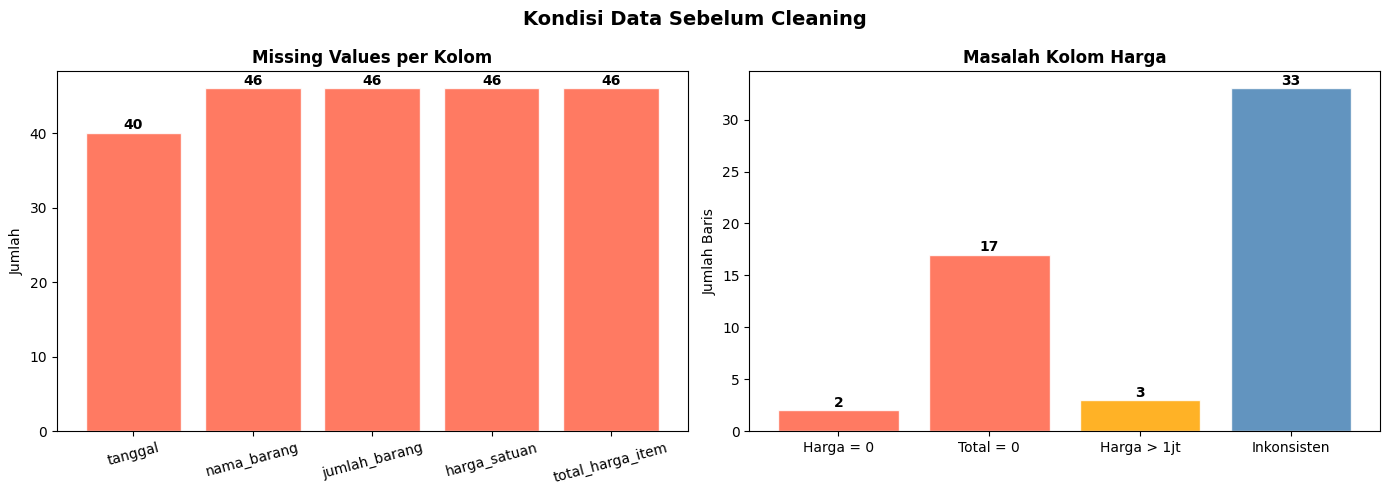

In [21]:
# Visualisasi kondisi data sebelum cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Missing values per kolom
missing_plot = df_primer.isnull().sum()
missing_plot = missing_plot[missing_plot > 0]
axes[0].bar(missing_plot.index, missing_plot.values, color='tomato', alpha=0.85, edgecolor='white')
for i, v in enumerate(missing_plot.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Missing Values per Kolom', fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=15)

# Chart 2: Masalah kolom harga — beda warna per jenis masalah
labels = ['Harga = 0', 'Total = 0', 'Harga > 1jt', 'Inkonsisten']
vals = [
    (df_primer['harga_satuan'] == 0).sum(),
    (df_primer['total_harga_item'] == 0).sum(),
    (df_primer['harga_satuan'] > 1_000_000).sum(),
    inkonsisten
]
colors_right = ['tomato', 'tomato', 'orange', 'steelblue']
axes[1].bar(labels, vals, color=colors_right, alpha=0.85, edgecolor='white')
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')
axes[1].set_title('Masalah Kolom Harga', fontweight='bold')
axes[1].set_ylabel('Jumlah Baris')

plt.suptitle('Kondisi Data Sebelum Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_kondisi_awal.png', dpi=120, bbox_inches='tight')
plt.show()

> **Insight:** Berdasarkan visualisasi kondisi awal, `df_primer` masih memiliki beberapa masalah kualitas data. Missing value ditemukan pada 5 kolom transaksi dengan jumlah terbesar pada `nama_barang`, `jumlah_barang`, `harga_satuan`, dan `total_harga_item` (masing-masing 46 baris, 13.6%), serta `tanggal` (40 baris, 11.9%). Pada kolom harga, inkonsistensi antara harga satuan dan total harga menjadi masalah terbesar dengan 33 baris, diikuti total harga bernilai 0 sebanyak 17 baris. Hal ini wajar karena data berasal dari hasil OCR langsung, sehingga perlu dilakukan cleaning sebelum digunakan untuk analisis transaksi.

## 6. Cleaning Pipeline

Cleaning dilakukan berdasarkan hasil assessing pada `df_primer`, yaitu dataset utama hasil ekstraksi OCR.  
Langkah cleaning yang dilakukan meliputi:

1. **Menghapus baris tanpa data transaksi utama:** baris yang tidak memiliki nama barang, harga satuan, dan jumlah barang.
2. **Membersihkan nama barang:** menghapus karakter noise OCR, teks non-produk, kode/nomor, dan nama barang yang sama dengan nama toko.
3. **Standarisasi tanggal:** mengubah berbagai format tanggal menjadi `datetime` dan menandai tanggal yang tidak valid.
4. **Validasi harga:** menghapus atau memperbaiki harga dan total harga yang bernilai 0, serta harga satuan di bawah Rp 500.
5. **Cek konsistensi harga:** membandingkan `harga_satuan × jumlah_barang` dengan `total_harga_item`, baris dengan selisih > 50% dihapus.
6. **Hapus jumlah barang ekstrem:** baris dengan jumlah barang > 200 unit per baris dihapus sebagai noise OCR.
7. **Handling outlier:** membatasi harga satuan ekstrem menggunakan persentil ke-99.
8. **Finalisasi data:** normalisasi format teks, hapus duplikat, dan reset index.

Output dari tahap ini adalah `df_clean`, yaitu dataset transaksi bersih yang siap digunakan untuk feature engineering dan analisis.

In [22]:
def clean_tanggal(val):
    """Standarisasi tanggal OCR ke format datetime."""
    if pd.isna(val):
        return None
    val = str(val).strip()
    formats = [
        '%Y-%m-%d', '%d-%m-%Y', '%m-%d-%Y',
        '%d/%m/%Y', '%Y/%m/%d', '%d.%m.%Y',
        '%d.%m.%y', '%Y.%m.%d', '%d-%m-%y',
    ]
    for fmt in formats:
        try:
            dt = pd.to_datetime(val, format=fmt)
            if pd.Timestamp('2000-01-01') <= dt <= pd.Timestamp('2027-12-31'):
                return dt
        except:
            continue
    return None

In [23]:
def clean_nama_barang(val):
    """Membersihkan nama barang dari karakter noise OCR."""
    if pd.isna(val):
        return None
    val = str(val).strip()
    val = re.sub(r'^[^a-zA-Z0-9]+', '', val)
    val = re.sub(r'[^a-zA-Z0-9\s\-\.&()/]+', ' ', val)
    val = re.sub(r'\s+', ' ', val).strip()
    return val if len(val) >= 3 else None

In [24]:
def is_noise_nama(val):
    """Mendeteksi teks yang bukan nama barang."""
    if pd.isna(val):
        return True
    v = str(val).strip().lower()
    noise_exact = {
        'jumlah', 'barang', 'tolal', 'total', 'promo',
        'gopay bsid', 'suht', 'goreng', 'amdk', 'pcs)',
        'y0.00', '1 000)', '2 000)', '32 72/',
    }
    noise_patterns = [
        r'^\d[\d\s\.,\-]+$',
        r'^\d{1,3}[\.,]\d{3}[\-\s]*$',
        r'^rp[\s\d\.,]+$',
        r'^\d+\s*[-–]\s*$',
    ]
    if v in noise_exact:
        return True
    for pat in noise_patterns:
        if re.match(pat, v):
            return True
    return False

In [25]:
df_clean = df_primer.copy()
n_awal   = len(df_clean)

# Step 1: Hapus baris yang tidak memiliki informasi transaksi utama
before = len(df_clean)
df_clean = df_clean.dropna(
    subset=['nama_barang', 'harga_satuan', 'jumlah_barang'], how='all'
)
print(f'Step 1 Hapus baris tanpa data transaksi utama : {before - len(df_clean)} baris')

Step 1 Hapus baris tanpa data transaksi utama : 46 baris


In [26]:
# Step 2: Bersihkan nama barang dan hapus teks non-produk
before = len(df_clean)
df_clean['nama_barang'] = df_clean['nama_barang'].apply(clean_nama_barang)

noise_keywords = [
    'subtotal', 'total', 'sub tot', 'cash',
    'change', 'debit', 'tanggal', 'faktur', 'jl.'
]

df_clean = df_clean[~(
    df_clean['nama_barang'].isna() |
    df_clean['nama_barang'].str.match(r'^[\d\s,\.]+$').fillna(False) |
    df_clean['nama_barang'].str.lower().str.contains(
        '|'.join(noise_keywords),
        regex=True
    ).fillna(False)
)]
print(f'Step 2 Hapus nama barang tidak valid/noise : {before - len(df_clean)} baris')

Step 2 Hapus nama barang tidak valid/noise : 36 baris


In [27]:
# Step 3: Hapus nama barang yang masih terdeteksi sebagai noise
before = len(df_clean)
df_clean = df_clean[~df_clean['nama_barang'].apply(is_noise_nama)]
print(f'Step 3 Hapus noise lanjutan pada nama barang : {before - len(df_clean)} baris')

Step 3 Hapus noise lanjutan pada nama barang : 23 baris


In [28]:
# Step 4: Hapus nama barang yang terdeteksi sebagai kode/nomor hasil OCR
before = len(df_clean)
df_clean = df_clean[
    ~df_clean['nama_barang'].str.match(r'^\d[\dA-Z]{5,}').fillna(False)
]
print(f'Step 4 Hapus nama barang berupa kode/nomor : {before - len(df_clean)} baris')

Step 4 Hapus nama barang berupa kode/nomor : 3 baris


In [29]:
# Step 5: Hapus baris nama barang == nama toko
before = len(df_clean)
df_clean = df_clean[
    df_clean['nama_barang'].str.lower().str.strip() !=
    df_clean['nama_toko'].str.lower().str.strip()
]
print(f'Step 5 Hapus nama barang yang sama dengan toko : {before - len(df_clean)} baris')

Step 5 Hapus nama barang yang sama dengan toko : 1 baris


In [30]:
# Step 6: Standardisasi tanggal
df_clean['tanggal_clean'] = df_clean['tanggal'].apply(clean_tanggal)
df_clean['tanggal_valid'] = df_clean['tanggal_clean'].notna()
print(f'Step 6 Tandai tanggal tidak valid : {(~df_clean["tanggal_valid"]).sum()} baris, ditandai tidak dihapus')

Step 6 Tandai tanggal tidak valid : 50 baris, ditandai tidak dihapus


In [31]:
# Step 7: Hapus baris tanpa informasi harga yang valid
before = len(df_clean)
df_clean = df_clean[~(
    (df_clean['harga_satuan'] == 0) &
    (df_clean['total_harga_item'] == 0)
)]
print(f'Step 7 Hapus baris tanpa informasi harga : {before - len(df_clean)} baris')

Step 7 Hapus baris tanpa informasi harga : 2 baris


In [32]:
# Step 8: Isi total harga kosong dari harga satuan x jumlah barang
mask_total_0 = (
    (df_clean['total_harga_item'] == 0) &
    (df_clean['harga_satuan'] > 0) &
    (df_clean['jumlah_barang'] > 0)
)

df_clean.loc[mask_total_0, 'total_harga_item'] = (
    df_clean.loc[mask_total_0, 'harga_satuan'] *
    df_clean.loc[mask_total_0, 'jumlah_barang']
)

print(f'Step 8 Isi total harga yang masih kosong : {mask_total_0.sum()} baris diisi')


Step 8 Isi total harga yang masih kosong : 8 baris diisi


In [33]:
# Step 9: Impute harga satuan dari total / jumlah
mask_impute = (
    (df_clean['harga_satuan'] == 0) &
    (df_clean['total_harga_item'] > 0) &
    (df_clean['jumlah_barang'] > 0)
)

df_clean.loc[mask_impute, 'harga_satuan'] = (
    df_clean.loc[mask_impute, 'total_harga_item'] /
    df_clean.loc[mask_impute, 'jumlah_barang']
).astype(int)

print(f'Step 9 Impute harga satuan dari total : {mask_impute.sum()} baris diisi')

Step 9 Impute harga satuan dari total : 0 baris diisi


In [34]:
# Step 10: Hapus harga satuan < 500
before = len(df_clean)
df_clean = df_clean[df_clean['harga_satuan'] >= 500]
print(f'Step 10 Hapus harga satuan < 500 : {before - len(df_clean)} baris')

Step 10 Hapus harga satuan < 500 : 14 baris


In [35]:
# Step 11: Drop inkonsistensi harga parah
before = len(df_clean)

df_clean['total_calc'] = (
    df_clean['harga_satuan'] *
    df_clean['jumlah_barang']
)

mask_inkonsisten = (
    (df_clean['total_harga_item'] > 0) &
    (df_clean['total_calc'] > 0) &
    (
        (df_clean['total_calc'] - df_clean['total_harga_item']).abs() /
        df_clean['total_harga_item'] > 0.5
    )
)

df_clean = df_clean[~mask_inkonsisten].drop(columns='total_calc')

print(f'Step 11 Hapus baris dengan harga tidak konsisten : {before - len(df_clean)} baris')

Step 11 Hapus baris dengan harga tidak konsisten : 19 baris


In [36]:
# Step 12: Hapus jumlah barang ekstrem (> 200 unit per baris)
before = len(df_clean)
df_clean = df_clean[df_clean['jumlah_barang'] <= 200]

print(f'Step 12 Hapus qty ekstrem > 200 : {before - len(df_clean)} baris')

Step 12 Hapus qty ekstrem > 200 : 1 baris


In [37]:
# Step 13: Batasi harga satuan ekstrem menggunakan persentil ke-99
p99 = df_clean['harga_satuan'].quantile(0.99)

df_clean['harga_satuan'] = df_clean['harga_satuan'].clip(upper=p99)

print(f'Step 13 Batasi outlier harga satuan p99 : Rp {p99:,.0f}')

Step 13 Batasi outlier harga satuan p99 : Rp 352,855


In [38]:
# Step 14: Rapikan format penulisan nama barang dan nama toko
df_clean['nama_barang'] = df_clean['nama_barang'].str.title().str.strip()
df_clean['nama_toko'] = df_clean['nama_toko'].str.title().str.strip()

print('Step 14 Rapikan format nama barang dan toko : selesai')

Step 14 Rapikan format nama barang dan toko : selesai


In [39]:
# Step 15: Hapus duplikat & reset index
before = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f'Step 15 Hapus duplikat dan reset index : {before - len(df_clean)} baris')

Step 15 Hapus duplikat dan reset index : 0 baris


### Ringkasan Hasil Cleaning

Setelah proses cleaning selesai, dilakukan rangkuman kondisi dataset untuk melihat jumlah data akhir, missing value, duplikat, kondisi harga, dan status tanggal.

In [40]:
print('=' * 55)
print('KONDISI DATA SETELAH CLEANING')
print('=' * 55)

# Ringkasan ukuran data
print(f'\nShape data akhir : {df_clean.shape}')
print(f'Baris awal       : {n_awal}')
print(f'Baris akhir      : {len(df_clean)}')
print(f'Baris terhapus   : {n_awal - len(df_clean)} ({(n_awal - len(df_clean)) / n_awal * 100:.1f}% dari data awal)')

# Missing value
print('\nMissing Values:')
missing = df_clean.isna().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('   Tidak ada missing value')
else:
    for col, val in missing.items():
        print(f'   {col:<20}: {val} baris ({val / len(df_clean) * 100:.1f}%)')

# Duplikat
print(f'\nDuplikat          : {df_clean.duplicated().sum()} baris')

# Validasi harga
print('\nValidasi Harga:')
print(f'   harga_satuan = 0      : {(df_clean["harga_satuan"] == 0).sum()} baris')
print(f'   total_harga_item = 0  : {(df_clean["total_harga_item"] == 0).sum()} baris')
print(f'   Min harga_satuan      : Rp {df_clean["harga_satuan"].min():,.0f}')
print(f'   Max harga_satuan      : Rp {df_clean["harga_satuan"].max():,.0f}')
print(f'   Median harga_satuan   : Rp {df_clean["harga_satuan"].median():,.0f}')

# Validasi tanggal
tanggal_valid = df_clean['tanggal_valid'].sum()
persen_tanggal_valid = df_clean['tanggal_valid'].mean() * 100

print('\nValidasi Tanggal:')
print(f'   Tanggal valid         : {tanggal_valid} dari {len(df_clean)} baris ({persen_tanggal_valid:.1f}%)')
print(f'   Tanggal tidak valid   : {len(df_clean) - tanggal_valid} baris')

# Preview data
display(df_clean.head())

KONDISI DATA SETELAH CLEANING

Shape data akhir : (192, 12)
Baris awal       : 337
Baris akhir      : 192
Baris terhapus   : 145 (43.0% dari data awal)

Missing Values:
   tanggal             : 19 baris (9.9%)
   tanggal_clean       : 41 baris (21.4%)

Duplikat          : 0 baris

Validasi Harga:
   harga_satuan = 0      : 0 baris
   total_harga_item = 0  : 0 baris
   Min harga_satuan      : Rp 500
   Max harga_satuan      : Rp 352,855
   Median harga_satuan   : Rp 15,145

Validasi Tanggal:
   Tanggal valid         : 151 dari 192 baris (78.6%)
   Tanggal tidak valid   : 41 baris


,nomor,filename,sumber,nama_toko,tanggal,nama_barang,jumlah_barang,harga_satuan,total_harga_item,raw_text,tanggal_clean,tanggal_valid
0,10,primer_0003.jpg,primer,Central Park,NaN,Popmierbaso57G,1.0,1200.0,1200.0,"Central Park\n3X4.000\nRp\nPOPMIERBASO57G\n12,...",NaT,False
1,12,primer_0005.jpg,primer,Titik Mula Coffee,06/05/2025,Steak-Brown Sauce,1.0,35000.0,35000.0,TITIK MULA COFFEE\nJ1.Dipokusumo No.28\nPurbal...,2025-05-06,True
2,13,primer_0005.jpg,primer,Titik Mula Coffee,06/05/2025,Sauce,1.0,35000.0,35000.0,TITIK MULA COFFEE\nJ1.Dipokusumo No.28\nPurbal...,2025-05-06,True
3,16,primer_0007.jpg,primer,Beepos,24-05-2023,Bakso,2.0,12000.0,24000.0,BEEPOS\nCafe Bee\nJ1.Kemang Selatan I No.20\nS...,2023-05-24,True
4,17,primer_0007.jpg,primer,Beepos,24-05-2023,Cah Kangkung,3.0,7500.0,22500.0,BEEPOS\nCafe Bee\nJ1.Kemang Selatan I No.20\nS...,2023-05-24,True


##7. Feature Engineering

Feature engineering dilakukan untuk menambahkan kolom baru yang membantu proses analisis, seperti `bulan`, `tahun`, `bulan_tahun`, dan `kategori_harga`.

In [41]:
# Mengekstrak komponen tanggal untuk analisis tren
df_clean['bulan'] = df_clean['tanggal_clean'].dt.month
df_clean['tahun'] = df_clean['tanggal_clean'].dt.year
df_clean['bulan_tahun'] = df_clean['tanggal_clean'].dt.to_period('M').astype(str)
print('Fitur bulan, tahun, bulan_tahun berhasil dibuat.')

Fitur bulan, tahun, bulan_tahun berhasil dibuat.


In [42]:
def kategorikan_harga(h):
    """Segmentasi item berdasarkan rentang harga satuan."""
    if h <= 5000:
        return 'Sangat Murah (<=5rb)'
    elif h <= 20000:
        return 'Murah (5-20rb)'
    elif h <= 50000:
        return 'Sedang (20-50rb)'
    elif h <= 100000:
        return 'Mahal (50-100rb)'
    else:
        return 'Sangat Mahal (>100rb)'

In [43]:
# Menambahkan kategori harga
df_clean['kategori_harga'] = df_clean['harga_satuan'].apply(kategorikan_harga)
print('Distribusi kategori harga:')
print(df_clean['kategori_harga'].value_counts().to_string())

Distribusi kategori harga:
kategori_harga
Murah (5-20rb)           90
Sedang (20-50rb)         44
Sangat Murah (<=5rb)     40
Mahal (50-100rb)          9
Sangat Mahal (>100rb)     9


In [44]:
# Feature Engineering Summary
print('=' * 50)
print('FEATURE ENGINEERING — SUMMARY')
print('=' * 50)
new_cols = ['tanggal_clean', 'tanggal_valid', 'bulan', 'tahun', 'bulan_tahun', 'kategori_harga']
print('\nFitur baru ditambahkan:')
for col in new_cols:
    print(f'  + {col} ({df_clean[col].dtype})')
print(f'\nFeature engineering selesai — shape: {df_clean.shape}')

FEATURE ENGINEERING — SUMMARY

Fitur baru ditambahkan:
  + tanggal_clean (datetime64[ns])
  + tanggal_valid (bool)
  + bulan (float64)
  + tahun (float64)
  + bulan_tahun (object)
  + kategori_harga (object)

Feature engineering selesai — shape: (192, 16)


## 8. Evaluasi: Sebelum vs Sesudah Cleaning

Evaluasi ini membandingkan kondisi dataset sebelum dan sesudah cleaning berdasarkan tiga aspek utama: jumlah baris, missing value pada kolom transaksi utama, dan jumlah baris dengan harga satuan valid.

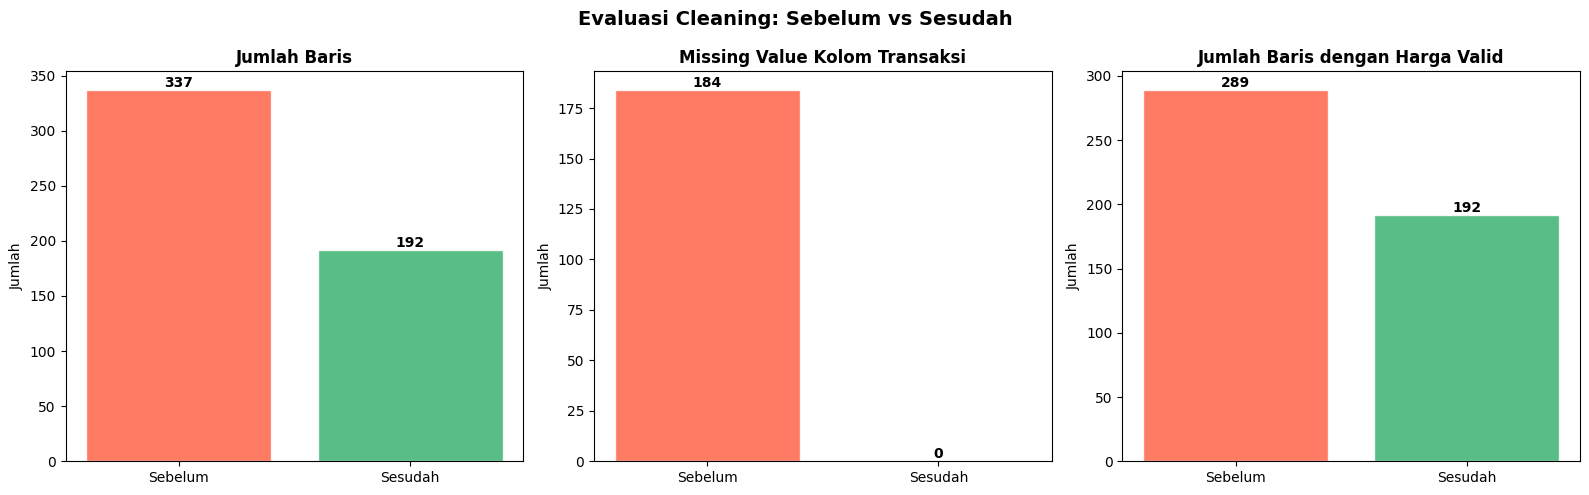

In [45]:
kolom_transaksi = [
    'nama_barang',
    'jumlah_barang',
    'harga_satuan',
    'total_harga_item'
]

before_rows = n_awal
after_rows = len(df_clean)

before_missing = df_primer[kolom_transaksi].isna().sum().sum()
after_missing = df_clean[kolom_transaksi].isna().sum().sum()

before_harga_valid = (df_primer['harga_satuan'] > 0).sum()
after_harga_valid = (df_clean['harga_satuan'] > 0).sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = ['Sebelum', 'Sesudah']
colors = ['tomato', 'mediumseagreen']

# Chart 1: Jumlah baris
bars = axes[0].bar(
    labels,
    [before_rows, after_rows],
    color=colors,
    alpha=0.85,
    edgecolor='white'
)
axes[0].set_title('Jumlah Baris', fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].bar_label(bars, fontweight='bold')

# Chart 2: Missing value kolom transaksi
bars = axes[1].bar(
    labels,
    [before_missing, after_missing],
    color=colors,
    alpha=0.85,
    edgecolor='white'
)
axes[1].set_title('Missing Value Kolom Transaksi', fontweight='bold')
axes[1].set_ylabel('Jumlah')
axes[1].bar_label(bars, fontweight='bold')

# Chart 3: Harga valid
bars = axes[2].bar(
    labels,
    [before_harga_valid, after_harga_valid],
    color=colors,
    alpha=0.85,
    edgecolor='white'
)
axes[2].set_title('Jumlah Baris dengan Harga Valid', fontweight='bold')
axes[2].set_ylabel('Jumlah')
axes[2].bar_label(bars, fontweight='bold')

plt.suptitle('Evaluasi Cleaning: Sebelum vs Sesudah', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(f'{OUTPUT_DIR}/02_evaluasi_cleaning.png', dpi=120, bbox_inches='tight')
plt.show()

> **Insight:** Setelah cleaning, jumlah baris berkurang dari 337 menjadi 192 karena data kosong, noise OCR, dan harga tidak valid telah dihapus. Missing value pada kolom transaksi utama turun menjadi 0, sehingga `nama_barang`, `jumlah_barang`, `harga_satuan`, dan `total_harga_item` sudah siap digunakan untuk analisis. Seluruh data akhir juga memiliki `harga_satuan > 0`.

## 9. EDA: Business Question 1

**Business Question 1:** Bagaimana performa OCR dalam mengekstrak informasi dari struk secara otomatis dan akurat?

In [46]:
# BQ1: Komparasi performa 3 model OCR
display(df_evaluasi)

,Nama Model,Rata-rata Waktu (Detik),Success Rate (%),Akurasi Jumlah Item (%),Akurasi Total Harga (%)
0,Paddle,5.26,73.33,27.30,26.09
1,Tesseract,2.64,60.00,13.67,16.05
2,EasyOCR,18.73,56.67,33.47,14.03


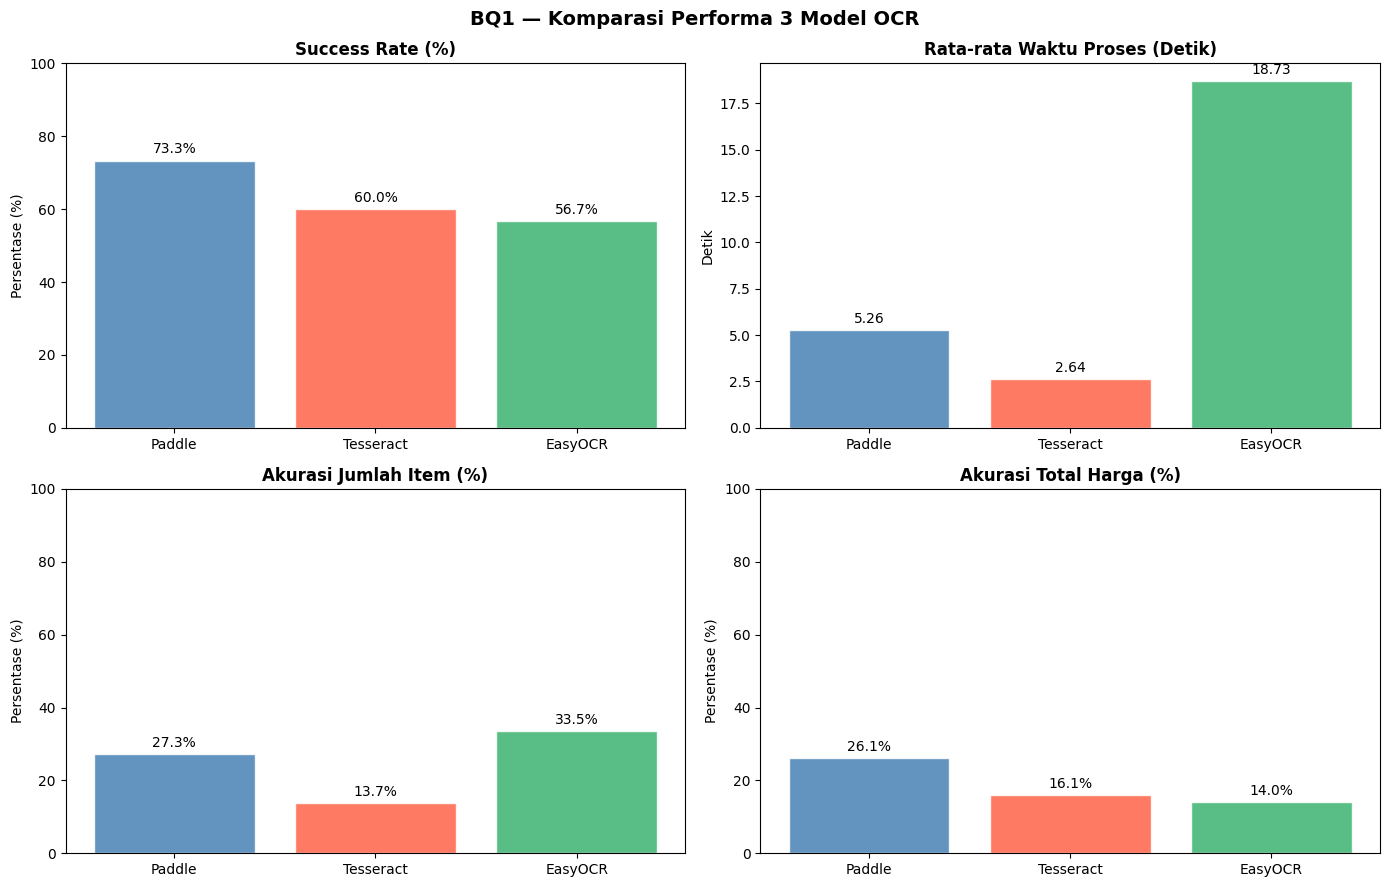

In [47]:
# BQ1: Komparasi Performa Model OCR

models = df_evaluasi['Nama Model']
colors = ['steelblue', 'tomato', 'mediumseagreen']

metrics = [
    ('Success Rate (%)', 'Success Rate (%)', 'Persentase (%)', '%.1f%%'),
    ('Rata-rata Waktu (Detik)', 'Rata-rata Waktu Proses (Detik)', 'Detik', '%.2f'),
    ('Akurasi Jumlah Item (%)', 'Akurasi Jumlah Item (%)', 'Persentase (%)', '%.1f%%'),
    ('Akurasi Total Harga (%)', 'Akurasi Total Harga (%)', 'Persentase (%)', '%.1f%%')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, title, ylabel, fmt) in zip(axes, metrics):
    bars = ax.bar(
        models,
        df_evaluasi[col],
        color=colors,
        alpha=0.85,
        edgecolor='white'
    )

    ax.bar_label(bars, fmt=fmt, padding=3)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)

    if '%' in col:
        ax.set_ylim(0, 100)

plt.suptitle('BQ1 — Komparasi Performa 3 Model OCR', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(f'{OUTPUT_DIR}/03_bq1_komparasi_model.png', dpi=120, bbox_inches='tight')
plt.show()

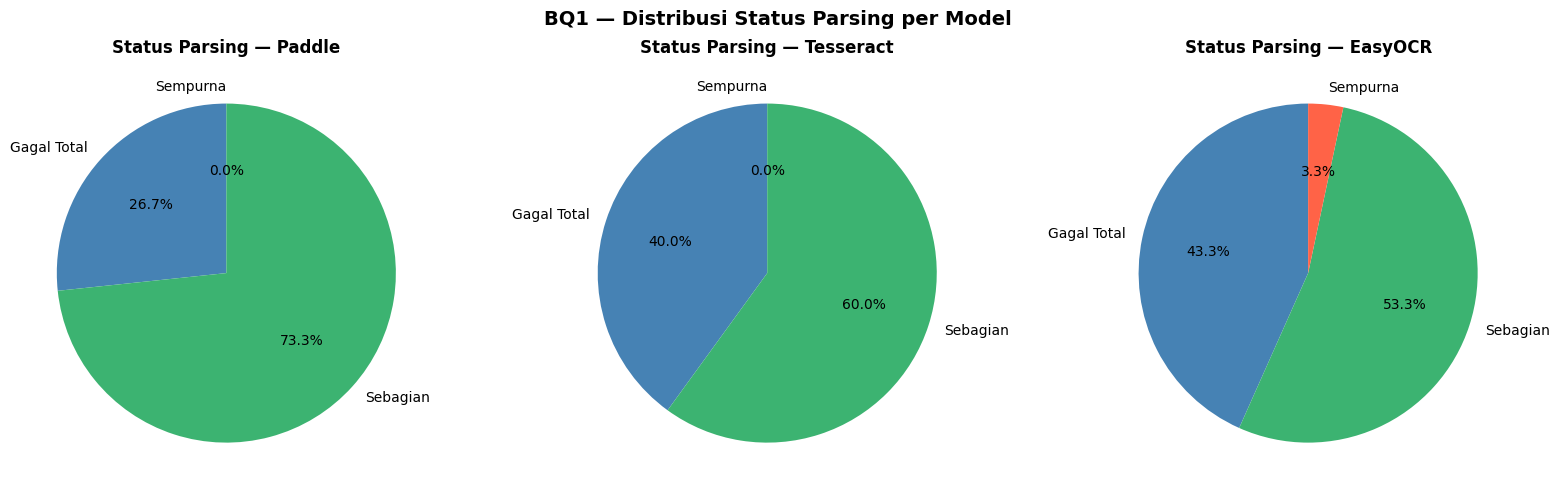

In [48]:
# BQ1: Distribusi Status Parsing per Model

status_counts = df_detail.groupby(['Model', 'Status']).size().unstack(fill_value=0)

label_map = {
    'Sebagian (Terekstrak tapi ada miss)': 'Sebagian',
    'Sempurna (100%)': 'Sempurna',
    'Gagal Total (0%)': 'Gagal Total'
}

status_counts = status_counts.rename(columns=label_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_status = ['steelblue', 'mediumseagreen', 'tomato']

for ax, model in zip(axes, ['Paddle', 'Tesseract', 'EasyOCR']):
    if model in status_counts.index:
        data = status_counts.loc[model]

        ax.pie(
            data.values,
            labels=data.index,
            autopct='%1.1f%%',
            colors=colors_status[:len(data)],
            startangle=90
        )

        ax.set_title(f'Status Parsing — {model}', fontweight='bold')

plt.suptitle('BQ1 — Distribusi Status Parsing per Model', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(f'{OUTPUT_DIR}/04_bq1_status_parsing.png', dpi=120, bbox_inches='tight')
plt.show()

### Insight BQ1

Berdasarkan hasil evaluasi, Paddle memiliki performa paling seimbang dibandingkan Tesseract dan EasyOCR. Paddle memperoleh success rate tertinggi sebesar 73.33% dan akurasi total harga tertinggi sebesar 26.09%, meskipun waktu prosesnya lebih lama dibandingkan Tesseract.

Tesseract memiliki waktu proses paling cepat (2.64 detik), tetapi akurasi jumlah item dan total harga paling rendah sehingga kurang andal untuk ekstraksi data transaksi. EasyOCR memiliki akurasi jumlah item tertinggi (33.5%), namun waktu prosesnya sangat lambat (18.73 detik) dan akurasi total harga paling rendah (14.0%), sehingga tidak efisien untuk deployment.

Dengan demikian, Paddle dipilih sebagai model OCR untuk proyek ini karena memiliki keseimbangan terbaik antara keberhasilan parsing, akurasi harga, dan waktu proses yang wajar.

## 10. EDA: Business Question 2

**Business Question 2:** Bagaimana pelaku usaha mikro dapat mengetahui laba dari setiap produk yang dijual secara sederhana?

In [49]:
# BQ2: Estimasi Laba Sederhana

def hitung_laba_per_item(df_struk, persen_margin=0.20):
    """Menghitung estimasi laba per item berdasarkan margin dari total harga."""

    df_out = df_struk[
        ['nama_barang', 'jumlah_barang', 'harga_satuan', 'total_harga_item']
    ].copy()

    df_out['margin_%'] = persen_margin * 100
    df_out['laba_total'] = df_out['total_harga_item'] * persen_margin
    df_out['harga_beli_est'] = df_out['total_harga_item'] - df_out['laba_total']
    df_out['laba_per_unit'] = df_out['laba_total'] / df_out['jumlah_barang']

    return df_out

In [50]:
# Demo menggunakan satu struk dari dataset bersih
sample_file = 'primer_0079.jpg'
sample_struk = df_clean[df_clean['filename'] == sample_file]

print(f'Demo struk  : {sample_file}')
print('Margin input: 20%')
print()

df_laba = hitung_laba_per_item(sample_struk, persen_margin=0.20)
display(df_laba)

Demo struk  : primer_0079.jpg
Margin input: 20%



,nama_barang,jumlah_barang,harga_satuan,total_harga_item,margin_%,laba_total,harga_beli_est,laba_per_unit
124,Nestle Pure Life 600,2.0,3600.0,7200.0,20.0,1440.0,5760.0,720.0
125,Le Minerale 6Ooml,2.0,3500.0,7000.0,20.0,1400.0,5600.0,700.0
126,Ultra Kcng Hijau 250,1.0,4900.0,4900.0,20.0,980.0,3920.0,980.0
127,Nutrijel Pwd.Strw.15,2.0,6600.0,13200.0,20.0,2640.0,10560.0,1320.0
128,Knzler Sngleskju 65,1.0,8700.0,8700.0,20.0,1740.0,6960.0,1740.0
129,Knzler Sngles Hot 65,1.0,8700.0,8700.0,20.0,1740.0,6960.0,1740.0
130,Kanzlr Bakso Ori 48G,2.0,8700.0,17400.0,20.0,3480.0,13920.0,1740.0


In [51]:
# Ringkasan laba struk demo
total_omzet = df_laba['total_harga_item'].sum()
total_laba = df_laba['laba_total'].sum()

print('Ringkasan Struk:')
print(f'   Total Omzet  : Rp {total_omzet:,.0f}')
print(f'   Total Laba   : Rp {total_laba:,.0f}')

if total_omzet > 0:
    print(f'   Margin Aktual: {total_laba / total_omzet * 100:.1f}%')

Ringkasan Struk:
   Total Omzet  : Rp 67,100
   Total Laba   : Rp 13,420
   Margin Aktual: 20.0%


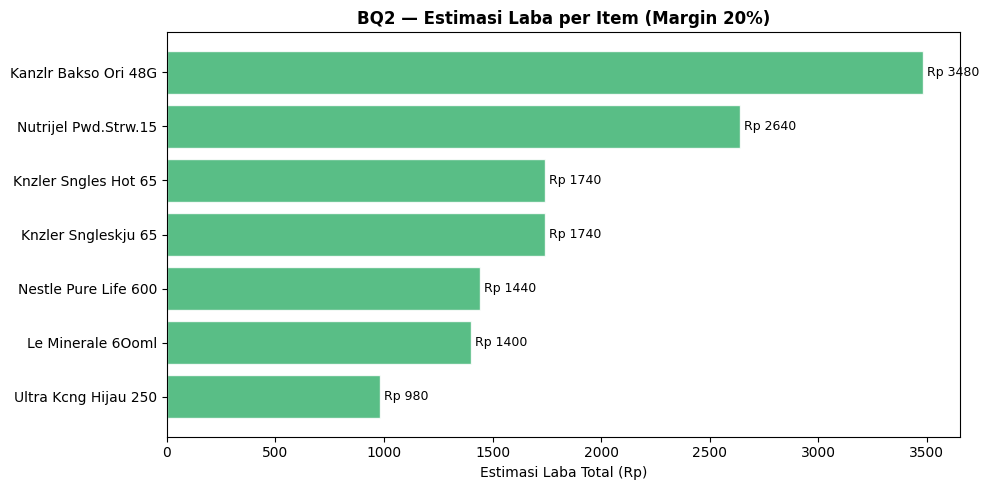

In [52]:
# Visualisasi estimasi laba per item
df_plot = (
    df_laba[df_laba['laba_total'] > 0]
    .sort_values('laba_total')
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    df_plot['nama_barang'],
    df_plot['laba_total'],
    color='mediumseagreen',
    alpha=0.85,
    edgecolor='white'
)

ax.bar_label(bars, fmt='Rp %.0f', padding=3, fontsize=9)
ax.set_title('BQ2 — Estimasi Laba per Item (Margin 20%)', fontweight='bold')
ax.set_xlabel('Estimasi Laba Total (Rp)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_bq2_laba_per_item.png', dpi=120, bbox_inches='tight')
plt.show()

### Insight BQ2

Dengan input persentase margin dari pengguna, sistem dapat langsung menghitung estimasi laba per item tanpa perlu memasukkan harga beli satu per satu. Berdasarkan demo struk `primer_0079.jpg` dengan margin 20%, total omzet struk sebesar **Rp 67.100** menghasilkan estimasi laba **Rp 13.420**.

Item dengan kontribusi laba tertinggi adalah **Kanzlr Bakso Ori 48G** (Rp 3.480) karena dibeli 2 unit, diikuti **Nutrijel Pwd.Strw.15** (Rp 2.640). Pola ini menunjukkan bahwa item dengan jumlah beli lebih dari 1 unit berkontribusi lebih besar terhadap total laba meskipun harga satuannya tidak selalu tertinggi.

Pendekatan ini praktis untuk pelaku UMKM yang tidak memiliki sistem pencatatan harga beli terstruktur — cukup input satu angka margin, sistem langsung menghasilkan laporan laba per item yang siap digunakan untuk pembukuan sederhana.

## 11. EDA: Business Question 3

**Business Question 3:** Bagaimana data transaksi dapat diolah menjadi laporan terstruktur untuk mendukung pengambilan keputusan bisnis?

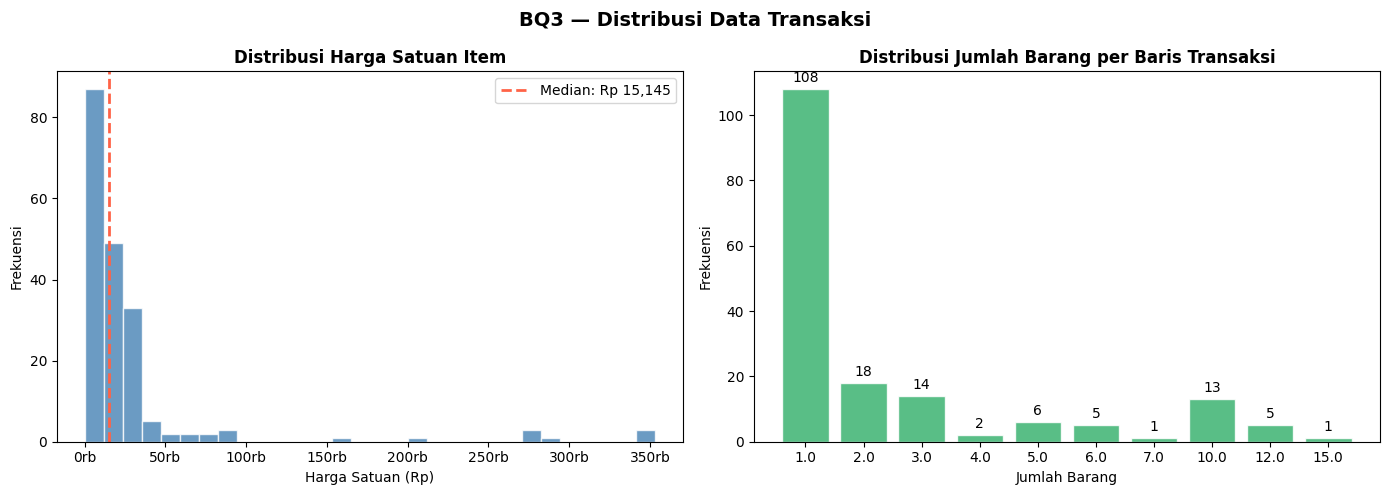

In [53]:
# BQ3: Distribusi Data Transaksi

df_harga = df_clean[df_clean['harga_satuan'] > 0]
median_harga = df_harga['harga_satuan'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Distribusi harga satuan
axes[0].hist(
    df_harga['harga_satuan'],
    bins=30,
    color='steelblue',
    alpha=0.8,
    edgecolor='white'
)

axes[0].axvline(
    median_harga,
    color='tomato',
    linestyle='--',
    linewidth=2,
    label=f'Median: Rp {median_harga:,.0f}'
)

axes[0].set_title('Distribusi Harga Satuan Item', fontweight='bold')
axes[0].set_xlabel('Harga Satuan (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}rb')
)
axes[0].legend()

# Chart 2: Distribusi jumlah barang
jumlah_counts = df_clean['jumlah_barang'].value_counts().sort_index().head(10)

bars = axes[1].bar(
    jumlah_counts.index.astype(str),
    jumlah_counts.values,
    color='mediumseagreen',
    alpha=0.85,
    edgecolor='white'
)

axes[1].bar_label(bars, padding=3)
axes[1].set_title('Distribusi Jumlah Barang per Baris Transaksi', fontweight='bold')
axes[1].set_xlabel('Jumlah Barang')
axes[1].set_ylabel('Frekuensi')

plt.suptitle('BQ3 — Distribusi Data Transaksi', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(f'{OUTPUT_DIR}/06_bq3_distribusi.png', dpi=120, bbox_inches='tight')
plt.show()

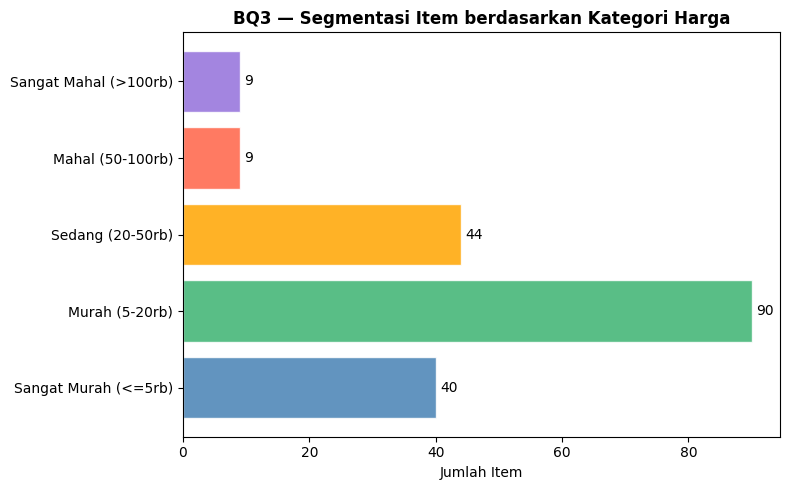

In [54]:
# BQ3: Segmentasi Kategori Harga

kat_order = [
    'Sangat Murah (<=5rb)',
    'Murah (5-20rb)',
    'Sedang (20-50rb)',
    'Mahal (50-100rb)',
    'Sangat Mahal (>100rb)'
]

kat_counts = df_clean['kategori_harga'].value_counts().reindex(kat_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))

colors_kat = [
    'steelblue',
    'mediumseagreen',
    'orange',
    'tomato',
    'mediumpurple'
]

bars = ax.barh(
    kat_counts.index,
    kat_counts.values,
    color=colors_kat,
    alpha=0.85,
    edgecolor='white'
)

ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('BQ3 — Segmentasi Item berdasarkan Kategori Harga', fontweight='bold')
ax.set_xlabel('Jumlah Item')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_bq3_kategori_harga.png', dpi=120, bbox_inches='tight')
plt.show()

In [55]:
# BQ3: Laporan Transaksi Terstruktur

df_clean['estimasi_laba_20'] = df_clean['total_harga_item'] * 0.20

laporan_struk = df_clean.groupby('filename').agg(
    nama_toko=('nama_toko', 'first'),
    tanggal_clean=('tanggal_clean', 'first'),
    tanggal_valid=('tanggal_valid', 'first'),
    jumlah_item=('nama_barang', 'count'),
    total_qty=('jumlah_barang', 'sum'),
    total_transaksi=('total_harga_item', 'sum'),
    estimasi_laba=('estimasi_laba_20', 'sum')
).reset_index().sort_values('total_transaksi', ascending=False)

# Filter
p95_transaksi = laporan_struk['total_transaksi'].quantile(0.95)
laporan_struk_filtered = laporan_struk[
    (laporan_struk['total_transaksi'] <= 500_000) &
    (laporan_struk['total_qty'] <= 50) &
    (laporan_struk['tanggal_valid'] == True) &
    (laporan_struk['nama_toko'].str.len() >= 5) &
    (laporan_struk['nama_toko'].str.contains(r'[A-Za-z]{5,}', regex=True, na=False)) &
    (~laporan_struk['nama_toko'].str.contains(
        r'Penjualan|Distribus|\d{8,}|^Shop$|^Tong$|^Trre$|Deeok|Distrab|Duplikat|Ptoomfa|Mamy Poko|Opnstd|Apaaja|Yangaku|Higuna|Wiguna',
        case=False, regex=True, na=False
    ))
]

display(laporan_struk_filtered.head(10))

,filename,nama_toko,tanggal_clean,tanggal_valid,jumlah_item,total_qty,total_transaksi,estimasi_laba
31,primer_0071.jpg,Tokosukatam,2026-01-24,True,8,27.0,353000.0,70600.0
4,primer_0011.jpg,Satetongseng,2018-01-11,True,5,20.0,292000.0,58400.0
2,primer_0007.jpg,Beepos,2023-05-24,True,4,11.0,172500.0,34500.0
16,primer_0051.jpg,Tokosukatant,2026-03-31,True,4,5.0,84500.0,16900.0
1,primer_0005.jpg,Titik Mula Coffee,2025-05-06,True,2,2.0,70000.0,14000.0
37,primer_0085.jpg,Tongtji,2025-10-13,True,1,3.0,17100.0,3420.0
46,primer_0105.jpg,Mixue,2024-05-12,True,1,2.0,8000.0,1600.0


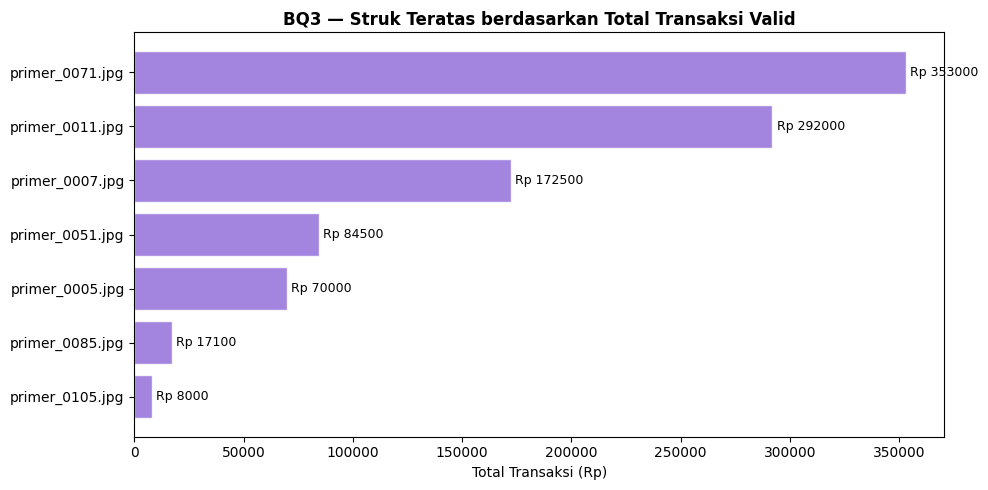

In [56]:
# BQ3: Visualisasi Top Struk

top_struk = (
    laporan_struk_filtered
    .sort_values('total_transaksi', ascending=False)
    .head(10)
    .sort_values('total_transaksi')
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    top_struk['filename'],
    top_struk['total_transaksi'],
    color='mediumpurple',
    alpha=0.85,
    edgecolor='white'
)

ax.bar_label(bars, fmt='Rp %.0f', padding=3, fontsize=9)
ax.set_title('BQ3 — Struk Teratas berdasarkan Total Transaksi Valid', fontweight='bold')
ax.set_xlabel('Total Transaksi (Rp)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_bq3_laporan_struk_filtered.png', dpi=120, bbox_inches='tight')
plt.show()

### Insight BQ3

Data transaksi hasil OCR berhasil diolah menjadi laporan terstruktur setelah melalui proses cleaning dan feature engineering.

Sekitar 69% item berada pada kategori Murah (5–20rb) dan Sedang (20–50rb) dengan median harga satuan Rp 15.145, mencerminkan pola belanja kebutuhan sehari-hari. Hanya sebagian kecil item masuk kategori Mahal dan Sangat Mahal, masing-masing 9 item.

Mayoritas transaksi bersifat satuan (1 unit per baris), bukan grosir. Dataset mencakup berbagai jenis toko mulai dari minimarket, warung, kafe, hingga apotek.

Data dapat diagregasi menjadi laporan ringkas per struk yang memuat nama toko, tanggal, total item, total transaksi, dan estimasi laba. Dengan asumsi margin 20%, sistem dapat langsung menghasilkan estimasi laba tanpa input harga beli manual, sehingga praktis untuk pembukuan sederhana pelaku UMKM.

> Catatan: Beberapa nama toko dan nilai total transaksi masih mengandung noise OCR residual. Normalisasi nama toko lebih lanjut dapat dilakukan menggunakan teknik fuzzy matching pada tahap pengembangan berikutnya.

## 12. Statistik Deskriptif Dataset Bersih

In [57]:
print('Statistik Deskriptif Dataset Bersih:')
display(
    df_clean[['jumlah_barang', 'harga_satuan', 'total_harga_item']]
    .describe()
    .round(2)
)

# Missing value detail
missing_detail = df_clean.isna().sum()
missing_detail = missing_detail[missing_detail > 0]

kolom_transaksi = [
    'nama_barang',
    'jumlah_barang',
    'harga_satuan',
    'total_harga_item'
]

missing_transaksi = df_clean[kolom_transaksi].isna().sum().sum()
missing_total = df_clean.isna().sum().sum()

print('\nRingkasan Akhir:')
print(f'   Total baris bersih        : {len(df_clean)}')
print(f'   Total struk unik          : {df_clean["filename"].nunique()}')
print(f'   Tanggal valid             : {df_clean["tanggal_valid"].sum()} ({df_clean["tanggal_valid"].mean()*100:.1f}%)')
print(f'   Rata-rata harga satuan    : Rp {df_clean["harga_satuan"].mean():,.0f}')
print(f'   Median harga satuan       : Rp {df_clean["harga_satuan"].median():,.0f}')
print(f'   Missing kolom transaksi   : {missing_transaksi}')
print(f'   Total missing value       : {missing_total} sel kosong')
print(f'   Duplikat                  : {df_clean.duplicated().sum()}')

print('\nDetail Missing Value:')
if len(missing_detail) == 0:
    print('   Tidak ada missing value')
else:
    for col, val in missing_detail.items():
        print(f'   {col:<20}: {val} ({val / len(df_clean) * 100:.1f}%)')

Statistik Deskriptif Dataset Bersih:


,jumlah_barang,harga_satuan,total_harga_item
count,192.00,192.00,192.00
mean,6.02,30162.56,403975.20
std,12.60,59378.73,2301218.57
min,1.00,500.00,500.00
25%,1.00,6825.00,10420.00
50%,1.00,15145.00,20000.00
75%,5.00,27057.50,81162.50
max,90.00,352855.40,24002356.00



Ringkasan Akhir:
   Total baris bersih        : 192
   Total struk unik          : 53
   Tanggal valid             : 151 (78.6%)
   Rata-rata harga satuan    : Rp 30,163
   Median harga satuan       : Rp 15,145
   Missing kolom transaksi   : 0
   Total missing value       : 142 sel kosong
   Duplikat                  : 0

Detail Missing Value:
   tanggal             : 19 (9.9%)
   tanggal_clean       : 41 (21.4%)
   bulan               : 41 (21.4%)
   tahun               : 41 (21.4%)


### Insight Statistik Deskriptif

Dataset bersih terdiri dari 192 baris transaksi dari 53 struk unik. Kolom transaksi utama seperti `nama_barang`, `jumlah_barang`, `harga_satuan`, dan `total_harga_item` sudah tidak memiliki missing value sehingga dapat digunakan untuk analisis transaksi.

Tanggal valid tersedia pada 151 baris (78.6%). Missing value yang masih ada berasal dari kolom tanggal dan fitur turunannya, bukan dari kolom transaksi utama.

Gap antara mean (Rp 30.163) dan median (Rp 15.145) harga satuan menunjukkan distribusi yang skewed ke kanan. Mayoritas item berharga rendah hingga menengah, namun ada sebagian kecil item dengan harga tinggi yang menarik rata-rata ke atas. Ini konsisten dengan temuan BQ3 bahwa sekitar 69% item berada di kategori Murah dan Sedang.

## 13. Export Dataset Final

In [58]:
kolom_final = [
    'filename', 'sumber', 'nama_toko', 'tanggal_clean', 'tanggal_valid',
    'nama_barang', 'jumlah_barang', 'harga_satuan', 'total_harga_item',
    'kategori_harga', 'bulan', 'tahun', 'bulan_tahun',
    'estimasi_laba_20'
]

df_final = df_clean[kolom_final].copy()

output_path = f'{OUTPUT_DIR}/dataset_ocr_clean_final.csv'
df_final.to_csv(output_path, index=False)

print(f'Dataset final disimpan ke: {output_path}')
print(f'Shape: {df_final.shape}')

display(df_final.head())

Dataset final disimpan ke: /content/drive/MyDrive/NOPI/output_csv/dataset_ocr_clean_final.csv
Shape: (192, 14)


,filename,sumber,nama_toko,tanggal_clean,tanggal_valid,nama_barang,jumlah_barang,harga_satuan,total_harga_item,kategori_harga,bulan,tahun,bulan_tahun,estimasi_laba_20
0,primer_0003.jpg,primer,Central Park,NaT,False,Popmierbaso57G,1.0,1200.0,1200.0,Sangat Murah (<=5rb),NaN,NaN,NaT,240.0
1,primer_0005.jpg,primer,Titik Mula Coffee,2025-05-06,True,Steak-Brown Sauce,1.0,35000.0,35000.0,Sedang (20-50rb),5.0,2025.0,2025-05,7000.0
2,primer_0005.jpg,primer,Titik Mula Coffee,2025-05-06,True,Sauce,1.0,35000.0,35000.0,Sedang (20-50rb),5.0,2025.0,2025-05,7000.0
3,primer_0007.jpg,primer,Beepos,2023-05-24,True,Bakso,2.0,12000.0,24000.0,Murah (5-20rb),5.0,2023.0,2023-05,4800.0
4,primer_0007.jpg,primer,Beepos,2023-05-24,True,Cah Kangkung,3.0,7500.0,22500.0,Murah (5-20rb),5.0,2023.0,2023-05,4500.0


## 14. Data Dictionary

**Model OCR:** PaddleOCR, berdasarkan hasil evaluasi performa model.  
**Total data bersih:** 192 baris  
**Total struk:** 53 file  

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `filename` | str | Nama file foto struk yang diproses OCR |
| `sumber` | str | Sumber data transaksi |
| `nama_toko` | str | Nama toko hasil ekstraksi OCR |
| `tanggal_clean` | datetime | Tanggal transaksi setelah standardisasi |
| `tanggal_valid` | bool | Penanda apakah tanggal berhasil distandardisasi |
| `nama_barang` | str | Nama item hasil OCR yang sudah dibersihkan |
| `jumlah_barang` | float | Jumlah unit item pada baris transaksi |
| `harga_satuan` | float | Harga per unit dalam Rupiah setelah validasi dan pembatasan outlier |
| `total_harga_item` | float | Total harga item hasil OCR atau hasil rekalkulasi jika nilai awal kosong |
| `kategori_harga` | str | Segmentasi item berdasarkan rentang harga satuan |
| `bulan` | float | Bulan transaksi dari tanggal_clean |
| `tahun` | float | Tahun transaksi dari tanggal_clean |
| `bulan_tahun` | str | Periode transaksi dalam format YYYY-MM |
| `estimasi_laba_20` | float | Estimasi laba berdasarkan asumsi margin 20% dari total_harga_item |

### Catatan Cleaning
- Dataset final berasal dari hasil OCR otomatis pada foto struk
- Tanggal tidak valid ditandai dengan `tanggal_valid=False` dan tidak dihapus
- Harga satuan ekstrem dibatasi menggunakan persentil ke-99
- Baris dengan jumlah barang > 200 unit dihapus sebagai noise OCR
- Baris dengan inkonsistensi harga × qty vs total > 50% dihapus
- Nama barang dibersihkan dari karakter noise OCR dan dinormalisasi
- Estimasi laba menggunakan asumsi margin 20%, bukan laba aktual